<div
    style="
        text-align: center;
        background-color: #4169E1;
        color: white;
        padding: 15px;
        margin: 0;
        border-radius: 15px 50px;
        font-size: 28px;
        font-family: 'Pacifico', cursive;
        font-weight: bold;
        overflow: hidden;
    "
>
    Read The data from database 
</div>

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

In [3]:
conn= create_engine(
     "mysql+pymysql://root@localhost/ecommerce"
)

In [4]:
def read_query(query):
    return pd.read_sql(query,conn)

<div
    style="
        text-align: center;
        background-color: #4169E1;
        color: white;
        padding: 15px;
        margin: 0;
        border-radius: 15px 50px;
        font-size: 28px;
        font-family: 'Pacifico', cursive;
        font-weight: bold;
        overflow: hidden;
    "
>
     Executive Sales Dashboard
</div>

In [5]:
query="""
select * from sales
"""
df = read_query(query)
print(read_query(query).columns)

Index(['transaction_id', 'customer_id', 'city', 'state', 'country', 'age',
       'gender', 'income', 'customer_segment', 'date', 'year', 'month', 'time',
       'total_purchases', 'amount', 'total_amount', 'product_category',
       'product_brand', 'feedback', 'shipping_method', 'payment_method',
       'order_status', 'ratings'],
      dtype='str')


Understand the overall business performance.

1. What is the total revenue generated?

In [6]:
query = """
SELECT SUM(total_amount) AS total_revenue
FROM sales;
"""

revenue = read_query(query)
print(f"Total Revenue: {revenue.loc[0, 'total_revenue']}")

Total Revenue: 402024952.72


2. How many total orders were placed?

In [7]:
query=""" 
select count('transaction_id') as total_order
from sales 
"""
order=read_query(query)
print(f'Total Order :{order.loc[0,'total_order']}')

Total Order :294115


3.What is the average order value (AOV)?

In [8]:
query=""" 
select avg(total_amount) as average_order_value
from sales 
"""
average= read_query(query)
print(f'Average Order Value: {average.loc[0,'average_order_value']}')

Average Order Value: 1366.897141


4. What is the average customer rating

In [9]:
query=""" 
select avg(ratings) as average_customer_rating
from sales 
"""
rating=read_query(query)
print(f"Average Customer Rating :{rating.loc[0,'average_customer_rating']}")


Average Customer Rating :3.16428


5. What is the total number of unique customers?

In [10]:
query = """
SELECT COUNT(DISTINCT customer_id) AS total_customers
FROM sales;
"""
customer = read_query(query)
print(f"Total Customers: {customer.loc[0, 'total_customers']}")

Total Customers: 86544


<div
    style="
        text-align: center;
        background-color: #4169E1;
        color: white;
        padding: 15px;
        margin: 0;
        border-radius: 15px 50px;
        font-size: 28px;
        font-family: 'Pacifico', cursive;
        font-weight: bold;
        overflow: hidden;
    "
>
    Marketing & Customer Intelligence
</div>

1. Which customer segment (customer_segment) generates the highest average revenue per transaction? 
   Is it the "Premium" segment, or are "Regular" users actually spending more per visit?

In [11]:
query = """
SELECT
    customer_segment,
    AVG(total_amount) AS average_revenue
FROM sales
GROUP BY customer_segment
ORDER BY average_revenue ASC;
"""
revenue=read_query(query)
print(revenue)

  customer_segment  average_revenue
0          Premium      1361.567210
1              New      1367.862842
2          Regular      1368.376216
3                       1531.056587


2. Which are the top 5 states or countries contributing to 80% of the company’s total revenue? Should marketing focus entirely on these regions?

In [12]:
query = """
SELECT
    state,
    SUM(total_amount) AS total_revenue,
    ROUND(
        SUM(total_amount) * 100.0 /
        (SELECT SUM(total_amount) FROM sales),
        2
    ) AS revenue_percentage
FROM sales
GROUP BY state
ORDER BY total_revenue DESC
LIMIT 5;
"""

state = read_query(query)
print(state)

             state  total_revenue  revenue_percentage
0          England    84662962.95               21.06
1           Berlin    70252028.47               17.47
2  New South Wales    60130987.23               14.96
3          Ontario    59901559.49               14.90
4      Connecticut    29005250.59                7.21


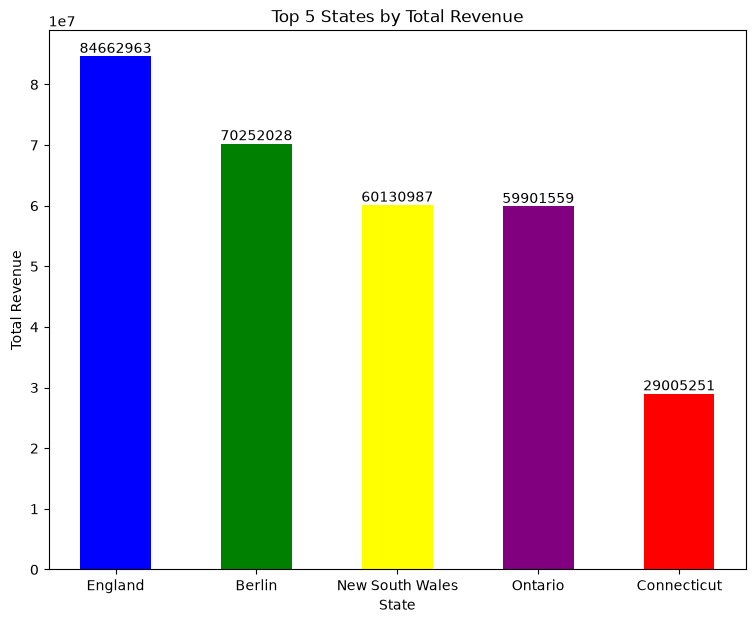

In [13]:
plt.figure(figsize=(9,7))

color = ['blue', 'green', 'yellow', 'purple', 'red']

bars = plt.bar(
    state['state'],
    state['total_revenue'],
    color=color,
    width=0.5    
)

plt.bar_label(bars, fmt='%.0f')

plt.title("Top 5 States by Total Revenue")
plt.xlabel("State")
plt.ylabel("Total Revenue")
# plt.xticks(rotation=30)

plt.show()

In [14]:
#top 5 country
query = """
SELECT
    country,
    SUM(total_amount) AS total_revenue,
    ROUND(
        SUM(total_amount) * 100.0 /
        (SELECT SUM(total_amount) FROM sales),
        2
    ) AS revenue_percentage
FROM sales
GROUP BY country
ORDER BY total_revenue DESC;
"""

country = read_query(query)
print(country)

     country  total_revenue  revenue_percentage
0        USA   1.267227e+08               31.52
1         UK   8.467449e+07               21.06
2    Germany   7.024666e+07               17.47
3  Australia   6.014346e+07               14.96
4     Canada   5.989262e+07               14.90
5              3.449732e+05                0.09


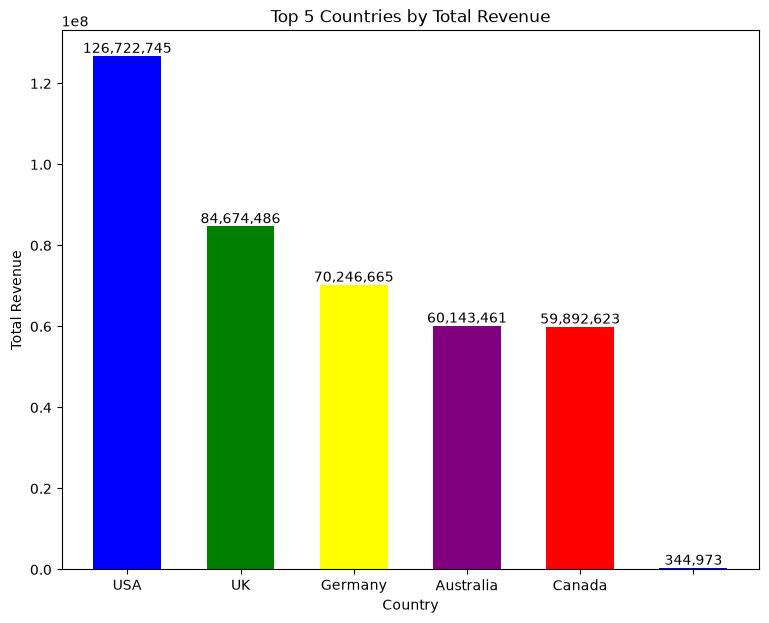

In [15]:
plt.figure(figsize=(9,7))

bar = plt.bar(
    country['country'],
    country['total_revenue'],
    width=0.6,
    color=color
)

plt.bar_label(
    bar,
    labels=[f'{x:,.0f}' for x in country['total_revenue']]
)

plt.title("Top 5 Countries by Total Revenue")
plt.xlabel("Country")
plt.ylabel("Total Revenue")

plt.show()

3. Do male and female customers show a statistically significant preference for different product_category? (e.g., Do women buy more "Clothing" and men more "Electronics"?)

In [16]:
query = """
SELECT
    product_category,
    SUM(CASE WHEN gender = 'Male' THEN 1 ELSE 0 END) AS male_purchases,
    SUM(CASE WHEN gender = 'Female' THEN 1 ELSE 0 END) AS female_purchases
FROM sales
GROUP BY product_category;
"""

products = read_query(query)
print(products)


  product_category  male_purchases  female_purchases
0                            163.0             112.0
1            Books         32461.0           20637.0
2         Clothing         32690.0           20586.0
3      Electronics         45232.0           24025.0
4          Grocery         39783.0           25271.0
5       Home Decor         32308.0           20537.0


4. If you group customers into age brackets (e.g., 18-25, 26-35, 36-50, 50+), which age bracket has the highest average spending per order, and which group makes the most total purchases?

In [17]:
query = """
SELECT
    CASE
        WHEN age BETWEEN 18 AND 25 THEN '18-25'
        WHEN age BETWEEN 26 AND 35 THEN '26-35'
        WHEN age BETWEEN 36 AND 50 THEN '36-50'
        ELSE '50+'
    END AS age_group,

    AVG(total_amount) AS average_spending,
    COUNT(*) AS total_purchases

FROM sales
GROUP BY age_group
ORDER BY average_spending DESC;
"""

customers = read_query(query)
print(customers)

  age_group  average_spending  total_purchases
0       50+       1396.803872            52522
1     36-50       1389.728523            67047
2     26-35       1377.723059            64356
3     18-25       1332.427137           110190


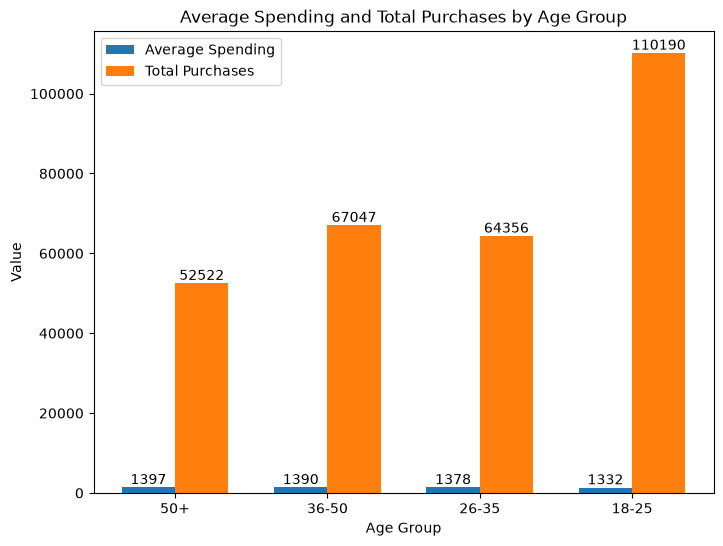

In [18]:


x = np.arange(len(customers['age_group']))
width = 0.35
plt.figure(figsize=(8,6))
bar1 = plt.bar(x - width/2, customers['average_spending'],
               width, label='Average Spending')
bar2 = plt.bar(x + width/2, customers['total_purchases'],
               width, label='Total Purchases')
plt.xticks(x, customers['age_group'])
plt.bar_label(bar1, fmt='%.0f')
plt.bar_label(bar2)
plt.title("Average Spending and Total Purchases by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Value")
plt.legend()
plt.show()

<div
    style="
        text-align: center;
        background-color: #4169E1;
        color: white;
        padding: 15px;
        margin: 0;
        border-radius: 15px 50px;
        font-size: 28px;
        font-family: 'Pacifico', cursive;
        font-weight: bold;
        overflow: hidden;
    "
>
    Sales Strategy & Revenue Trends
</div>

1. Which specific month of the year generates the highest total revenue, and which month has the highest volume of transactions? (Useful for planning holiday sales).

In [19]:

query = """
WITH MonthlySales AS (
    SELECT
        YEAR(date) AS year,
        MONTH(date) AS month,
        SUM(total_amount) AS total_revenue
    FROM sales
    GROUP BY
        YEAR(date),
        MONTH(date)
),
RankedSales AS (
    SELECT *,
           RANK() OVER (
               PARTITION BY year
               ORDER BY total_revenue DESC
           ) AS revenue_rank
    FROM MonthlySales
)
SELECT *
FROM RankedSales
WHERE revenue_rank <= 2
ORDER BY year, revenue_rank;
"""

months = read_query(query)
print(months)

     year  month  total_revenue  revenue_rank
0     NaN    NaN      446850.01             1
1  2023.0    3.0    34309190.01             1
2  2023.0    8.0    34211854.78             2
3  2024.0    1.0    33828226.46             1
4  2024.0    2.0    32073343.47             2


2. Which day of the week has the highest average order value? If weekends are for volume (many cheap items), and weekdays are for high-value purchases, sales strategy changes drastically.

In [20]:
query = """
SELECT
    DAYNAME(date) AS day_name,
    AVG(total_amount) AS avg_order_value
FROM sales
GROUP BY DAYNAME(date)
ORDER BY avg_order_value DESC;
"""

weeks_sales = read_query(query).head(7)
print(weeks_sales)

    day_name  avg_order_value
0     Friday      1380.197516
1   Thursday      1372.030599
2   Saturday      1367.264593
3  Wednesday      1365.707818
4     Monday      1362.970984
5    Tuesday      1361.064007
6     Sunday      1359.721732


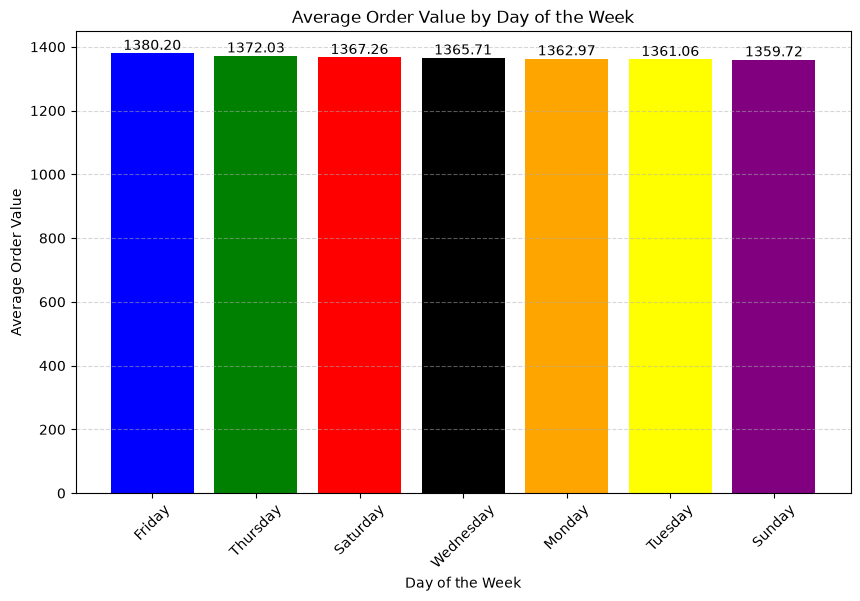

In [21]:
plt.figure(figsize=(10,6))

colors = ['blue', 'green', 'red', 'black', 'orange', 'yellow', 'purple']

bars = plt.bar(
    weeks_sales['day_name'],
    weeks_sales['avg_order_value'],
    color=colors
)

plt.bar_label(bars, fmt='%.2f')

plt.title("Average Order Value by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Average Order Value")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

3. Are "New" customers generating more revenue than "Regular" customers in the most recent 3 months, or is the business heavily reliant on returning/regular buyers?

In [22]:
query=""" 
SELECT
    customer_segment,
    ROUND(SUM(total_amount),0) AS total_revenue
FROM sales
WHERE date >= (
    SELECT DATE_SUB(MAX(date), INTERVAL 3 MONTH)
    FROM sales
)
GROUP BY customer_segment
ORDER BY total_revenue DESC;
"""
customers= read_query(query).head(3)
print(customers)

  customer_segment  total_revenue
0          Regular     49583729.0
1              New     30737661.0
2          Premium     21508887.0


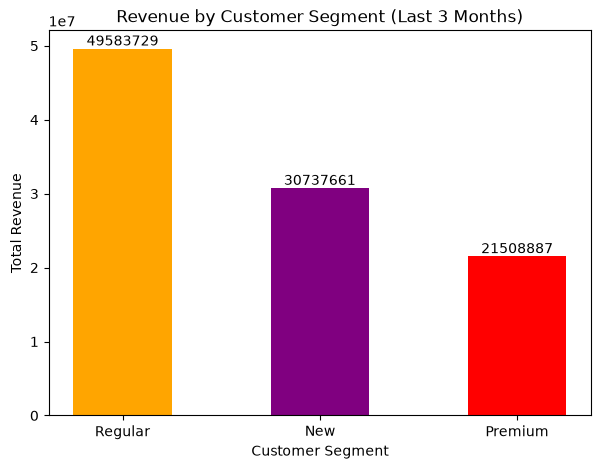

In [23]:
plt.figure(figsize=(7,5))

colors = ['orange','purple', 'red']

bar_cos = plt.bar(
    customers['customer_segment'],
    customers['total_revenue'],
    width=0.5,
    color=colors
)

plt.bar_label(bar_cos, fmt='%.0f')

plt.title("Revenue by Customer Segment (Last 3 Months)")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")

plt.show()

4. If you split customers by income (Low, Medium, High), which group is most likely to buy higher quantities (quantity) per order?

In [24]:
query = """
SELECT
    income,
    ROUND(AVG(total_purchases), 2) AS avg_quantity_per_order
FROM sales
GROUP BY income
ORDER BY avg_quantity_per_order DESC;
"""

levels = read_query(query)
print(levels)

   income  avg_quantity_per_order
0                            5.43
1  Medium                    5.37
2     Low                    5.36
3    High                    5.35



<div
    style="
        text-align: center;
        background-color: #4169E1;
        color: white;
        padding: 15px;
        margin: 0;
        border-radius: 15px 50px;
        font-size: 28px;
        font-family: 'Pacifico', cursive;
        font-weight: bold;
        overflow: hidden;
    "
>
    Product & Inventory Managements
</div>

1. Which product_category has the highest total revenue contribution for the entire company?

In [25]:
query=""" 
SELECT 
    product_category,
    sum(total_amount) as total_revenue
FROM sales
GROUP BY product_category
ORDER BY total_revenue DESC;
"""
product_category_revenue=read_query(query).head(5)
print(product_category_revenue)

  product_category  total_revenue
0      Electronics    94878869.95
1          Grocery    88857788.18
2         Clothing    72959861.52
3            Books    72603127.67
4       Home Decor    72353640.31


2.  Look at the order_status. Which product_category experiences the highest percentage of "Cancelled" or "Pending" orders compared to "Shipped"? (This highlights supply chain or quality control issues for specific items).

In [26]:
query=""" 
SELECT
    product_category,

    SUM(CASE
            WHEN order_status IN ('Cancelled','Pending')
            THEN 1
            ELSE 0
        END) AS issue_orders,

    SUM(CASE
            WHEN order_status='Shipped'
            THEN 1
            ELSE 0
        END) AS shipped_orders,

    ROUND(
        SUM(CASE
                WHEN order_status IN ('Cancelled','Pending')
                THEN 1
                ELSE 0
            END) *100.0 /
        COUNT(*),
        2
    ) AS issue_percentage
FROM sales
GROUP BY product_category
ORDER BY issue_percentage DESC;
"""
order=read_query(query)
print(order)

  product_category  issue_orders  shipped_orders  issue_percentage
0            Books        9142.0         11389.0             17.20
1          Grocery       11181.0         16928.0             17.17
2         Clothing        9117.0         11402.0             17.09
3       Home Decor        8832.0         11576.0             16.69
4                           44.0            58.0             16.00
5      Electronics        9167.0         11783.0             13.22


3.  Which are the top 2 highest-grossing product brands overall? Additionally, are these top 2 brands heavily concentrated in a single product category (e.g., does the top brand sell mostly Electronics), or are they diversified across multiple categories?"

In [27]:
query=""" 
WITH TopBrands AS (
    SELECT
        product_brand
    FROM sales
    GROUP BY product_brand
    ORDER BY SUM(total_amount) DESC
    LIMIT 2
)

SELECT
    s.product_brand,
    s.product_category,
    ROUND(SUM(s.total_amount), 0) AS total_revenue
FROM sales s
JOIN TopBrands t
    ON s.product_brand = t.product_brand
GROUP BY
    s.product_brand,
    s.product_category
ORDER BY
    s.product_brand,
    total_revenue DESC;
"""
brand_revenue=read_query(query)
print(brand_revenue)

  product_brand product_category  total_revenue
0         Pepsi          Grocery     40430378.0
1         Pepsi                         19506.0
2       Samsung      Electronics     24689247.0
3       Samsung                         24023.0




<div
    style="
        text-align: center;
        background-color: #4169E1;
        color: white;
        padding: 15px;
        margin: 0;
        border-radius: 15px 50px;
        font-size: 28px;
        font-family: 'Pacifico', cursive;
        font-weight: bold;
        overflow: hidden;
    "
>
   Logistics & Operational Efficiency
</div>

1. Which shipping_method (Express vs. Standard vs. Same Day) has the highest percentage of order_status marked as "Delivered"?

In [40]:
query=""" 
SELECT
    shipping_method,
    COUNT(*) AS total_orders,
    SUM(CASE
            WHEN order_status = 'Delivered' THEN 1
            ELSE 0
        END) AS delivered_orders,
    ROUND(
        SUM(CASE
                WHEN order_status = 'Delivered' THEN 1
                ELSE 0
            END) * 100.0 / COUNT(*),
        2
    ) AS delivered_percentage
FROM sales
GROUP BY shipping_method
ORDER BY delivered_percentage DESC;
"""
shipping_method=read_query(query)
print(shipping_method)

  shipping_method  total_orders  delivered_orders  delivered_percentage
0        Same-Day        101417           45184.0                 44.55
1         Express         99660           43264.0                 43.41
2        Standard         92710           39172.0                 42.25
3                           328             131.0                 39.94


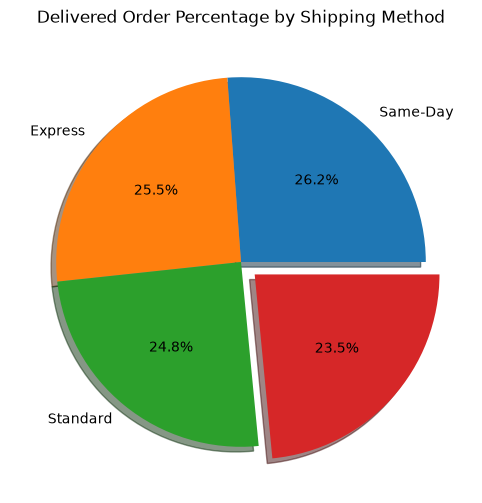

In [66]:
plt.figure(figsize=(8,6))
plt.title("Delivered Order Percentage by Shipping Method")
explode = (0,0,0,0.1)
plt.pie(
    shipping_method['delivered_percentage'],
    autopct='%1.1f%%',
    labels=shipping_method['shipping_method'],
    shadow=True,
    explode=explode
    )
plt.show()

2. Which payment method has the highest order completion (Delivered) rate?

In [68]:
query=""" 
SELECT
    payment_method,
    SUM(
        CASE
            WHEN order_status = 'Delivered' THEN 1
            ELSE 0
        END ) AS delivered_orders,
    ROUND(
        SUM(
            CASE
                WHEN order_status = 'Delivered' THEN 1
                ELSE 0
            END) * 100.0 / COUNT(*),
        1
    ) AS delivered_percentage
FROM sales
GROUP BY payment_method
ORDER BY delivered_percentage DESC;

"""
payment_method=read_query(query)
print(payment_method)

  payment_method  delivered_orders  delivered_percentage
0                            139.0                  47.9
1         PayPal           26890.0                  44.8
2           Cash           31668.0                  44.5
3    Credit Card           38224.0                  43.8
4     Debit Card           30830.0                  40.9



<div
    style="
        text-align: center;
        background-color: #4169E1;
        color: white;
        padding: 15px;
        margin: 0;
        border-radius: 15px 50px;
        font-size: 28px;
        font-family: 'Pacifico', cursive;
        font-weight: bold;
        overflow: hidden;
    "
>
   Customer Experience & Feedback

</div>

1. Does the shipping method affect customer satisfaction? Do customers who select "Express" or "Same Day" shipping give higher rating scores compared to those who choose "Standard" shipping

In [77]:
query="""
SELECT
    shipping_method,
    COUNT(*) AS total_orders,
    ROUND(AVG(ratings), 2) AS average_rating
FROM sales
GROUP BY shipping_method
ORDER BY average_rating DESC;
    """
rating=read_query(query)
print(rating)

  shipping_method  total_orders  average_rating
0        Same-Day        101417            3.20
1         Express         99660            3.15
2        Standard         92710            3.14
3                           328            3.10


2. Which payment method has the highest percentage of pending orders, and could this indicate potential payment processing or gateway issues

In [89]:
query=""" 
SELECT
    payment_method,
    COUNT(*) AS total_orders,
    SUM(
        CASE
            WHEN order_status = 'Pending' THEN 1
            ELSE 0
        END
    ) AS pending_orders,
    ROUND(
        SUM(
            CASE
                WHEN order_status = 'Pending' THEN 1
                ELSE 0
            END
        ) * 100.0 / COUNT(*),2) AS pending_percentage
FROM sales
GROUP BY payment_method
ORDER BY pending_percentage DESC;;
"""
relation=read_query(query)
print(relation)

  payment_method  total_orders  pending_orders  pending_percentage
0     Debit Card         75358         12823.0               17.02
1    Credit Card         87350         14336.0               16.41
2           Cash         71131         11069.0               15.56
3         PayPal         59986          9221.0               15.37
4                          290            34.0               11.72


3. Which product categories receive the highest percentage of customer feedback, and are customers more likely to leave feedback for certain categories than others?

In [ ]:
query=""" 
SELECT
    product_category,
    COUNT(*) AS total_orders,
    SUM(
        CASE
            WHEN feedback IS NOT NULL
                 AND feedback <> ''
            THEN 1
            ELSE 0
        END
    ) AS feedback_count,
    ROUND(
        SUM(
            CASE
                WHEN feedback IS NOT NULL
                     AND feedback <> ''
                THEN 1
                ELSE 0
            END
        ) * 100.0 / COUNT(*),
        2
    ) AS feedback_percentage

FROM sales
GROUP BY product_category
ORDER BY feedback_percentage DESC;
"""
feedbacks=read_query(query)
print(feedbacks)

  product_category  total_orders  feedback_count  feedback_percentage
0                            275           275.0               100.00
1          Grocery         65112         65082.0                99.95
2      Electronics         69326         69283.0                99.94
3         Clothing         53340         53307.0                99.94
4            Books         53150         53115.0                99.93
5       Home Decor         52912         52873.0                99.93
